In [1]:
import sys
sys.path.append(
    "/data/user/gsommani/alertstack3.12/lib/python3.12/site-packages/"
)
sys.path.append("../..")

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from agn_radio_catalogue import (
    AstrogeoAGNCatalogue, AverageFluxWeightHypothesis
)
from alertstack import alertstack_data_dir, is_outside_GP
from astropy.io import fits
from blazar_catalogue import (
    Fermi4FGLBlazarCatalogue, AverageFluxWeightHypothesis, data_lc
)

In [2]:
rd_cat_obj = AstrogeoAGNCatalogue()

In [3]:
rd_cat_obj.data

,Comm name,Source_Name,ra_deg,dec_deg,N of obs,S band map,S band unresolved,C band map,C band unresolved,X band map,X band unresolved,U band map,U band unresolved,K band map,K band unresolved,ra_rad,dec_rad,bkg_pdf
0,2357-326,J0000-3221,0.085000,-32.350343,17,0.581,0.436,-9.99,-9.99,0.278,0.133,-9.99,-9.99,-9.99,-9.99,0.001484,-0.564620,6.935229e-310
1,2358+406,J0000+4054,0.221171,40.900503,16,0.802,0.116,-9.99,-9.99,0.238,0.051,-9.99,-9.99,-9.99,-9.99,0.003860,0.713848,6.935229e-310
2,2358-161,J0001-1551,0.272203,-15.851965,18,0.313,0.179,-9.99,-9.99,0.192,0.099,-9.99,-9.99,-9.99,-9.99,0.004751,-0.276669,4.683248e-310
3,2358+189,J0001+1914,0.285923,19.242723,770,0.255,0.195,0.156,0.127,0.251,0.186,-9.99,-9.99,-9.99,-9.99,0.004990,0.335849,4.683248e-310
4,2358-080,J0001-0746,0.325104,-7.774145,28,0.209,0.106,-9.99,-9.99,0.175,0.053,-9.99,-9.99,-9.99,-9.99,0.005674,-0.135684,-1.356844e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378,2355+042,J2358+0430,359.620196,4.506899,23,0.188,0.165,-9.99,-9.99,0.153,0.105,-9.99,-9.99,-9.99,-9.99,6.276556,0.078660,7.866023e-02
3379,2356+196,J2358+1955,359.692021,19.922306,85,0.773,0.502,-9.99,-9.99,0.469,0.221,0.377,0.182,-9.99,-9.99,6.277810,0.347710,3.477098e-01
3380,2356+390,J2358+3922,359.749396,39.374529,16,0.326,0.117,-9.99,-9.99,0.305,0.180,-9.99,-9.99,-9.99,-9.99,6.278811,0.687215,6.872152e-01
3381,2356+385,J2359+3850,359.888253,38.845088,9256,0.416,0.297,-9.99,-9.99,0.320,0.206,-9.99,-9.99,-9.99,-9.99,6.281235,0.677975,6.779747e-01


In [4]:
rd_cat_obj.data["X band map"]

0       0.278
1       0.238
2       0.192
3       0.251
4       0.175
        ...  
3378    0.153
3379    0.469
3380    0.305
3381    0.320
3382    0.463
Name: X band map, Length: 3383, dtype: float64

In [5]:
len(rd_cat_obj.data)

3383

In [8]:
alertstack_data_dir = "../data/"
with fits.open(os.path.join(alertstack_data_dir, "table-4LAC-DR3-h.fits")) as hdul:
    cat = hdul[1].data
    header = hdul[1].header
cat = np.sort(cat, order="Energy_Flux100")[::-1]

#blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]
blazar_class = ["bll", "BLL", "fsrq", "FSRQ", "bcu", "BCU"]

mask = np.array([x["CLASS"] in blazar_class for x in cat])
blazars = np.array(cat[mask])
mask_e = np.array([x["Energy_Flux100"]>10**(-11.6) for x in blazars])
fermi_df = np.array(blazars[mask_e])
#fermi_df = fermicat.data
#fermi_df.keys()

In [9]:
fermi_ra = fermi_df["RA_Counterpart"]
fermi_de = fermi_df["DEC_Counterpart"]
fermi_er = fermi_df["Unc_Counterpart"]

In [10]:
radio_df = rd_cat_obj.data
rfc_ra = radio_df["ra_deg"]
rfc_de = radio_df["dec_deg"]

In [11]:
ang_mask = np.array([
    sum(
        (
            ra < ( fermi_ra + fermi_er / np.cos(fermi_de * np.pi / 180.) )
        ) & (
            ra > ( fermi_ra - fermi_er / np.cos(fermi_de * np.pi / 180.) )
        ) & (de < ( fermi_de + fermi_er )) & (de > ( fermi_de - fermi_er ))
    ) for ra, de in zip(rfc_ra, rfc_de)
])
#ra_mask[ra_mask>1] = 1
#de_mask[de_mask>1] = 1
ang_mask

array([0, 0, 0, ..., 1, 0, 0], shape=(3383,))

In [12]:
ang_mask = []
energy_fluxes = []
for ra, de in zip(rfc_ra, rfc_de):
    ra_less = ra < ( fermi_ra + fermi_er / np.cos(fermi_de * np.pi / 180.) )
    ra_more = ra > ( fermi_ra - fermi_er / np.cos(fermi_de * np.pi / 180.) )
    de_less = de < ( fermi_de + fermi_er )
    de_more = de > ( fermi_de - fermi_er )
    ra_mask = ra_less & ra_more
    de_mask = de_less & de_more
    ang_mask_fermi = ra_mask & de_mask
    if sum(ang_mask_fermi) == True:
        energy_flux = fermi_df[ang_mask_fermi]['Energy_Flux100'][0]
        energy_fluxes.append(energy_flux)
    ang_mask.append(sum(ang_mask_fermi))
#ra_mask[ra_mask>1] = 1
#de_mask[de_mask>1] = 1
ang_mask = np.array(ang_mask)
energy_fluxes = np.array(energy_fluxes)
#energy_fluxes

In [13]:
ang_mask_fermi = np.array([
    sum(
        (
            rfc_ra < ( ra + er / np.cos(de * np.pi / 180.) )
        ) & (
            rfc_ra > ( ra - er / np.cos(de * np.pi / 180.) )
        ) & (rfc_de < ( de + er )) & (rfc_de > ( de - er ))
    ) for ra, de, er in zip(fermi_ra, fermi_de, fermi_er)
])
#ra_mask_fermi[ra_mask_fermi>1] = 1
#de_mask_fermi[de_mask_fermi>1] = 1
ang_mask_fermi

array([1, 1, 1, ..., 0, 0, 0], shape=(1905,))

In [14]:
sum(ang_mask), sum(ang_mask_fermi)

(np.int64(734), np.int64(734))

In [15]:
sum(ang_mask>1), sum(ang_mask_fermi>1)

(np.int64(0), np.int64(0))

In [16]:
radio_flux = radio_df['X band map'].to_numpy()[ang_mask == True]
#energ_flux = fermi_df['Energy_Flux100'].to_numpy()[ang_mask_fermi == True]
len(radio_flux), len(energy_fluxes)

(734, 734)

In [17]:
ang_mask

array([0, 0, 0, ..., 1, 0, 0], shape=(3383,))

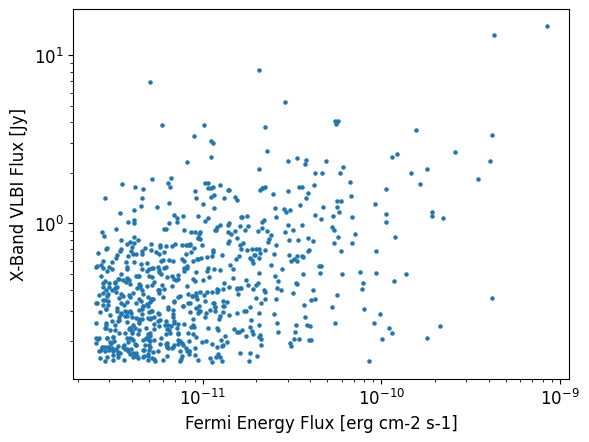

In [25]:
plt.scatter(energy_fluxes, radio_flux, s=5)
#plt.xlim(0,5e-10)
#plt.ylim(0,16)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fermi Energy Flux [erg cm-2 s-1]", fontsize="large")
plt.ylabel("X-Band VLBI Flux [Jy]", fontsize="large")

plt.xticks(fontsize="large")
plt.yticks(fontsize="large")
plt.savefig("fermi_rfc_flux_comparison", dpi=200, bbox_inches="tight")

In [17]:
sum(ra_mask), sum(de_mask)

(np.int64(0), np.int64(0))

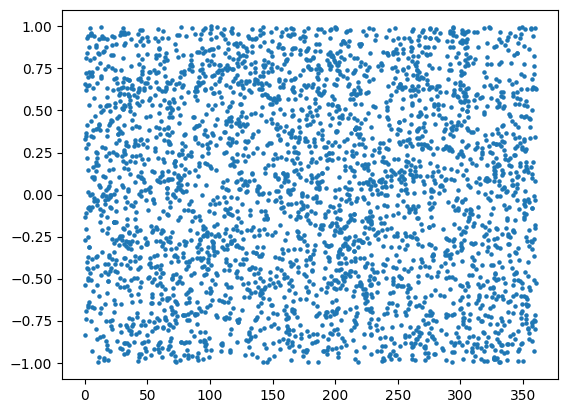

In [18]:
plt.scatter(rd_cat_obj.data['ra_deg'], np.sin(rd_cat_obj.data['dec_rad']), s=5)

In [19]:
rd_cat_obj.scramble()

,Comm name,Source_Name,ra_deg,dec_deg,N of obs,S band map,S band unresolved,C band map,C band unresolved,X band map,X band unresolved,U band map,U band unresolved,K band map,K band unresolved,ra_rad,dec_rad,bkg_pdf
0,2357-326,J0000-3221,153.913965,-1.788987,17,0.581,0.436,-9.99,-9.99,0.278,0.133,-9.99,-9.99,-9.99,-9.99,2.686305,-0.031224,7.797230e-08
1,2358+406,J0000+4054,289.558123,71.576500,16,0.802,0.116,-9.99,-9.99,0.238,0.051,-9.99,-9.99,-9.99,-9.99,5.053743,1.249246,9.995863e-08
2,2358-161,J0001-1551,69.581921,-64.349904,18,0.313,0.179,-9.99,-9.99,0.192,0.099,-9.99,-9.99,-9.99,-9.99,1.214434,-1.123118,8.809341e-08
3,2358+189,J0001+1914,115.721871,-49.599363,770,0.255,0.195,0.156,0.127,0.251,0.186,-9.99,-9.99,-9.99,-9.99,2.019728,-0.865672,5.857434e-08
4,2358-080,J0001-0746,53.772425,-21.426390,28,0.209,0.106,-9.99,-9.99,0.175,0.053,-9.99,-9.99,-9.99,-9.99,0.938506,-0.373961,8.568424e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378,2355+042,J2358+0430,67.799339,13.098663,23,0.188,0.165,-9.99,-9.99,0.153,0.105,-9.99,-9.99,-9.99,-9.99,1.183322,0.228615,9.374331e-08
3379,2356+196,J2358+1955,330.685855,64.713047,85,0.773,0.502,-9.99,-9.99,0.469,0.221,0.377,0.182,-9.99,-9.99,5.771557,1.129456,6.950218e-08
3380,2356+390,J2358+3922,335.759895,58.856079,16,0.326,0.117,-9.99,-9.99,0.305,0.180,-9.99,-9.99,-9.99,-9.99,5.860116,1.027232,5.847886e-08
3381,2356+385,J2359+3850,14.931013,-32.869204,9256,0.416,0.297,-9.99,-9.99,0.320,0.206,-9.99,-9.99,-9.99,-9.99,0.260595,-0.573676,6.858128e-08


In [20]:
bl_cat_obj = Fermi4FGLBlazarCatalogue()

In [7]:
bl_cat = bl_cat_obj.data
bl_cat["ra_rad"]

0       5.995142
1       3.386663
2       5.901875
3       2.899318
4       3.983098
          ...   
1900    5.483441
1901    2.822245
1902    1.041543
1903    3.583526
1904    1.833467
Name: ra_rad, Length: 1905, dtype: float32

In [13]:
for dtype in bl_cat.dtypes:
    print(dtype.descr)

[('', '|O')]
[('', '<i2')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f8')]
[('', '<f4')]
[('', '|O')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<i2')]
[('', '|O')]
[('', '|O')]
[('', '<f4')]
[('', '<f4')]
[('', '|O')]
[('', '<f8')]
[('', '<f8')]
[('', '<f8')]
[('', '|O')]
[('', '<f4')]
[('', '|O')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f4')]
[('', '<f8')]


In [23]:
bl_cat.to_records(index=False)[bl_cat.to_records(index=False).dtype.descr[0][0]]

array(['4FGL J2253.9+1609', '4FGL J1256.1-0547', '4FGL J2232.6+1143', ...,
       '4FGL J0358.7+7649', '4FGL J1341.2+3958', '4FGL J0700.1-6311'],
      shape=(1905,), dtype=object)

In [30]:
a = 4.84578973489584908520
type(np.float64(a))

numpy.float64

In [24]:
bl_cat[bl_cat.to_records(index=False).dtype.descr[0][0]]

0       4FGL J2253.9+1609
1       4FGL J1256.1-0547
2       4FGL J2232.6+1143
3       4FGL J1104.4+3812
4       4FGL J1512.8-0906
              ...        
1900    4FGL J2056.7-3209
1901    4FGL J1046.8-2534
1902    4FGL J0358.7+7649
1903    4FGL J1341.2+3958
1904    4FGL J0700.1-6311
Name: Source_Name, Length: 1905, dtype: object

In [15]:
bl_cat

,Source_Name,DataRelease,ra_rad,dec_rad,ra_deg,dec_deg,GLON,GLAT,Signif_Avg,Flux1000,...,Unc_HE_EPeak,HE_nuFnuPeak,Unc_HE_nuFnuPeak,nu_syn,nuFnu_syn,Variability_Index,Frac_Variability,Unc_Frac_Variability,Highest_energy,bkg_pdf
0,4FGL J2253.9+1609,1,5.995142,0.281881,343.496307,16.150600,86.118523,-38.184860,454.905396,7.406493e-08,...,5.742596,1.837138e-04,1.738388e-06,1.285287e+13,4.632101e-11,77426.656250,0.964517,0.205662,80.511398,7.947286e-08
1,4FGL J1256.1-0547,1,3.386663,-0.101032,194.041504,-5.788700,305.095154,57.063187,302.454376,4.088560e-08,...,11.592375,7.723492e-05,9.603697e-07,5.152287e+12,3.527435e-11,29785.236328,0.954598,0.203570,107.557999,7.947286e-08
2,4FGL J2232.6+1143,1,5.901875,0.204738,338.152496,11.730600,77.438484,-38.583153,345.948486,4.129105e-08,...,11.758326,7.555657e-05,7.944049e-07,2.951209e+12,4.880452e-12,84340.757812,1.463127,0.311969,97.931900,7.947286e-08
3,4FGL J1104.4+3812,1,2.899318,0.666838,166.118698,38.207001,179.832916,65.035706,343.769196,3.419173e-08,...,532364.875000,6.816407e-05,4.779828e-06,1.659587e+16,2.198240e-10,1618.067383,0.280627,0.060206,815.901978,7.947286e-08
4,4FGL J1512.8-0906,1,3.983098,-0.158937,228.214706,-9.106400,351.287537,40.131222,245.814133,3.381026e-08,...,5.781490,1.008965e-04,3.868754e-06,1.096478e+13,1.113402e-11,7448.419922,0.466078,0.099493,230.845993,7.947286e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1900,4FGL J2056.7-3209,1,5.483441,-0.561319,314.178009,-32.161201,12.244465,-39.371586,5.591945,1.713469e-10,...,354.622040,4.570632e-07,2.035035e-07,4.786301e+12,1.777354e-12,7.566792,0.000000,10.000000,-inf,7.947286e-08
1901,4FGL J1046.8-2534,1,2.822245,-0.446366,161.702698,-25.574900,270.559845,29.350193,10.163866,2.025259e-10,...,9636.473633,3.676892e-07,8.425447e-08,2.951209e+16,1.782009e-12,10.363155,0.000000,10.000000,53.753201,7.947286e-08
1902,4FGL J0358.7+7649,1,1.041543,1.340977,59.675999,76.832298,132.977448,17.773304,9.239629,2.150074e-10,...,1512.424683,3.059505e-07,3.589935e-07,0.000000e+00,0.000000e+00,5.356588,0.000000,10.000000,28.162001,7.947286e-08
1903,4FGL J1341.2+3958,1,3.583526,0.697674,205.320908,39.973801,87.282600,73.517265,12.603315,2.061140e-10,...,258435.875000,3.419252e-07,1.238874e-07,2.676086e+17,2.829026e-12,12.437265,0.159849,0.306186,101.767998,7.947286e-08


In [5]:
for b in bl_cat:
    print(b)

Source_Name
DataRelease
ra_rad
dec_rad
ra_deg
dec_deg
GLON
GLAT
Signif_Avg
Flux1000
Unc_Flux1000
Energy_Flux100
Unc_Energy_Flux100
SpectrumType
PL_Index
Unc_PL_Index
Pivot_Energy
LP_Index
Unc_LP_Index
LP_beta
Unc_LP_beta
Flags
CLASS
ASSOC1
ASSOC_PROB_BAY
ASSOC_PROB_LR
Counterpart_Catalog
RA_Counterpart
DEC_Counterpart
Unc_Counterpart
VLBI_Counterpart
Redshift
SED_class
HE_EPeak
Unc_HE_EPeak
HE_nuFnuPeak
Unc_HE_nuFnuPeak
nu_syn
nuFnu_syn
Variability_Index
Frac_Variability
Unc_Frac_Variability
Highest_energy
bkg_pdf


In [4]:
bl_cat['bkg_pdf']

0       7.947286e-08
1       7.947286e-08
2       7.947286e-08
3       7.947286e-08
4       7.947286e-08
            ...     
1900    7.947286e-08
1901    7.947286e-08
1902    7.947286e-08
1903    7.947286e-08
1904    7.947286e-08
Name: bkg_pdf, Length: 1905, dtype: float64

In [5]:
bl_cat

,Source_Name,DataRelease,ra_rad,dec_rad,ra_deg,dec_deg,GLON,GLAT,Signif_Avg,Flux1000,...,Unc_HE_EPeak,HE_nuFnuPeak,Unc_HE_nuFnuPeak,nu_syn,nuFnu_syn,Variability_Index,Frac_Variability,Unc_Frac_Variability,Highest_energy,bkg_pdf
0,4FGL J2253.9+1609,1,5.995142,0.281881,343.496307,16.150600,86.118523,-38.184860,454.905396,7.406493e-08,...,5.742596,1.837138e-04,1.738388e-06,1.285287e+13,4.632101e-11,77426.656250,0.964517,0.205662,80.511398,7.947286e-08
1,4FGL J1256.1-0547,1,3.386663,-0.101032,194.041504,-5.788700,305.095154,57.063187,302.454376,4.088560e-08,...,11.592375,7.723492e-05,9.603697e-07,5.152287e+12,3.527435e-11,29785.236328,0.954598,0.203570,107.557999,7.947286e-08
2,4FGL J2232.6+1143,1,5.901875,0.204738,338.152496,11.730600,77.438484,-38.583153,345.948486,4.129105e-08,...,11.758326,7.555657e-05,7.944049e-07,2.951209e+12,4.880452e-12,84340.757812,1.463127,0.311969,97.931900,7.947286e-08
3,4FGL J1104.4+3812,1,2.899318,0.666838,166.118698,38.207001,179.832916,65.035706,343.769196,3.419173e-08,...,532364.875000,6.816407e-05,4.779828e-06,1.659587e+16,2.198240e-10,1618.067383,0.280627,0.060206,815.901978,7.947286e-08
4,4FGL J1512.8-0906,1,3.983098,-0.158937,228.214706,-9.106400,351.287537,40.131222,245.814133,3.381026e-08,...,5.781490,1.008965e-04,3.868754e-06,1.096478e+13,1.113402e-11,7448.419922,0.466078,0.099493,230.845993,7.947286e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1900,4FGL J2056.7-3209,1,5.483441,-0.561319,314.178009,-32.161201,12.244465,-39.371586,5.591945,1.713469e-10,...,354.622040,4.570632e-07,2.035035e-07,4.786301e+12,1.777354e-12,7.566792,0.000000,10.000000,-inf,7.947286e-08
1901,4FGL J1046.8-2534,1,2.822245,-0.446366,161.702698,-25.574900,270.559845,29.350193,10.163866,2.025259e-10,...,9636.473633,3.676892e-07,8.425447e-08,2.951209e+16,1.782009e-12,10.363155,0.000000,10.000000,53.753201,7.947286e-08
1902,4FGL J0358.7+7649,1,1.041543,1.340977,59.675999,76.832298,132.977448,17.773304,9.239629,2.150074e-10,...,1512.424683,3.059505e-07,3.589935e-07,0.000000e+00,0.000000e+00,5.356588,0.000000,10.000000,28.162001,7.947286e-08
1903,4FGL J1341.2+3958,1,3.583526,0.697674,205.320908,39.973801,87.282600,73.517265,12.603315,2.061140e-10,...,258435.875000,3.419252e-07,1.238874e-07,2.676086e+17,2.829026e-12,12.437265,0.159849,0.306186,101.767998,7.947286e-08


In [6]:
scramble = bl_cat_obj.scramble()

(-1.0, 1.0)

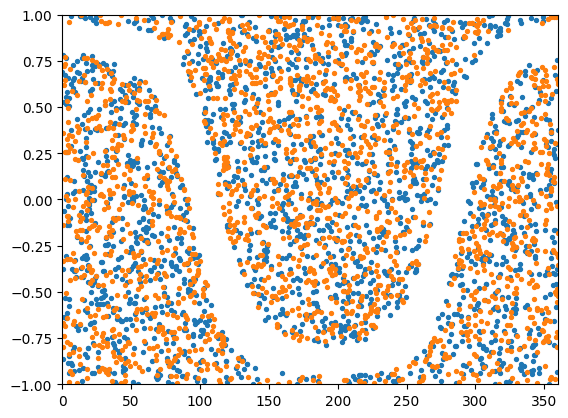

In [7]:
plt.scatter(scramble['ra_deg'], np.sin(scramble['dec_rad']), s=8)
plt.scatter(bl_cat['ra_deg'], np.sin(bl_cat['dec_rad']), s=8)
plt.xlim(0, 360.)
plt.ylim(-1., 1.)

In [8]:
bl_cat['bkg_pdf']

0       7.947286e-08
1       7.947286e-08
2       7.947286e-08
3       7.947286e-08
4       7.947286e-08
            ...     
1900    7.947286e-08
1901    7.947286e-08
1902    7.947286e-08
1903    7.947286e-08
1904    7.947286e-08
Name: bkg_pdf, Length: 1905, dtype: float64

In [9]:
AverageFluxWeightHypothesis.weight_catalogue(bl_cat)

0       8.440041e-10
1       4.273501e-10
2       4.197115e-10
3       4.171065e-10
4       4.048376e-10
            ...     
1900    2.519530e-12
1901    2.517273e-12
1902    2.516697e-12
1903    2.515174e-12
1904    2.513237e-12
Name: Energy_Flux100, Length: 1905, dtype: float64

In [10]:
bl_cat["Energy_Flux100"]

0       8.440041e-10
1       4.273501e-10
2       4.197115e-10
3       4.171065e-10
4       4.048376e-10
            ...     
1900    2.519530e-12
1901    2.517273e-12
1902    2.516697e-12
1903    2.515174e-12
1904    2.513237e-12
Name: Energy_Flux100, Length: 1905, dtype: float64